## Data preparation

In [203]:
import matplotlib.pyplot as plt
from torch.functional import F
import yfinance as yf
from torch import nn
import numpy as np
import torch

In [70]:
data = yf.download("BTC-USD", start="2020-06-01", end="2026-06-01")

[*********************100%***********************]  1 of 1 completed


In [71]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-05-27,74344.703125,76014.296875,74136.500000,75825.304688,33802172927
2026-05-28,73536.554688,74460.125000,72493.414062,74339.570312,40148145327
2026-05-29,73372.523438,74218.562500,72435.625000,73537.031250,34457929250
2026-05-30,73754.835938,74020.757812,73125.234375,73370.851562,19563589191
2026-05-31,73579.687500,74153.500000,73315.015625,73753.750000,17445435650


In [72]:
data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

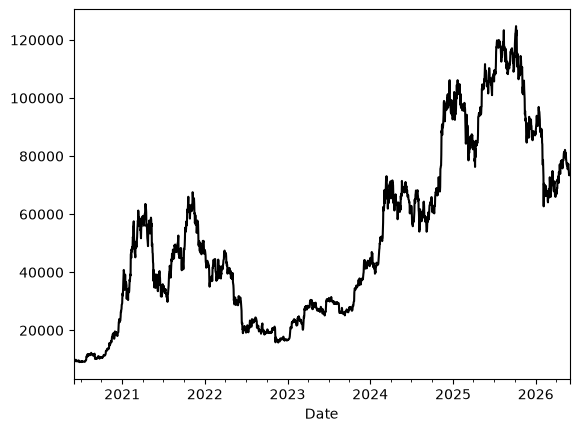

In [73]:
data['Close']['BTC-USD'].plot(cmap='gray');

In [74]:
values = data['Close']['BTC-USD'].values
len(values)

2191

In [75]:
# sliding window
windows = []
window_len = 80 # experiment with that later
images = []
for i in range(len(values) - window_len + 1):
    orig_window = values[i:i+window_len]
    windows.append(orig_window)

    # slice normalization
    # min-max scaling
    window = np.array(orig_window)
    max_value, min_value = window.max(), window.min()
    if min_value == max_value: # handle no change in values
        window = np.zeros_like(window)
    else:
        window = (window - min_value) / (max_value - min_value)

    matrix = np.zeros((window_len, window_len), dtype=np.float32)
    # where to place our value in a column
    for col_idx in range(window_len):
        # our values are from 0 to 1, so if value is 0.34 then
        # it signalises that it should be 34% from the bottom
        # so then it should be 66% from the top
        value = window[col_idx]
        value_row_idx = round((1 - window[col_idx]) * (window_len - 1))
        matrix[value_row_idx][col_idx] = 1 # drawing line on matrix
    images.append(matrix)

print(f'{len(windows)} {window_len}-day windows generated, \nso that {len(images)} training data graphs has been created')

2112 80-day windows generated, 
so that 2112 training data graphs has been created


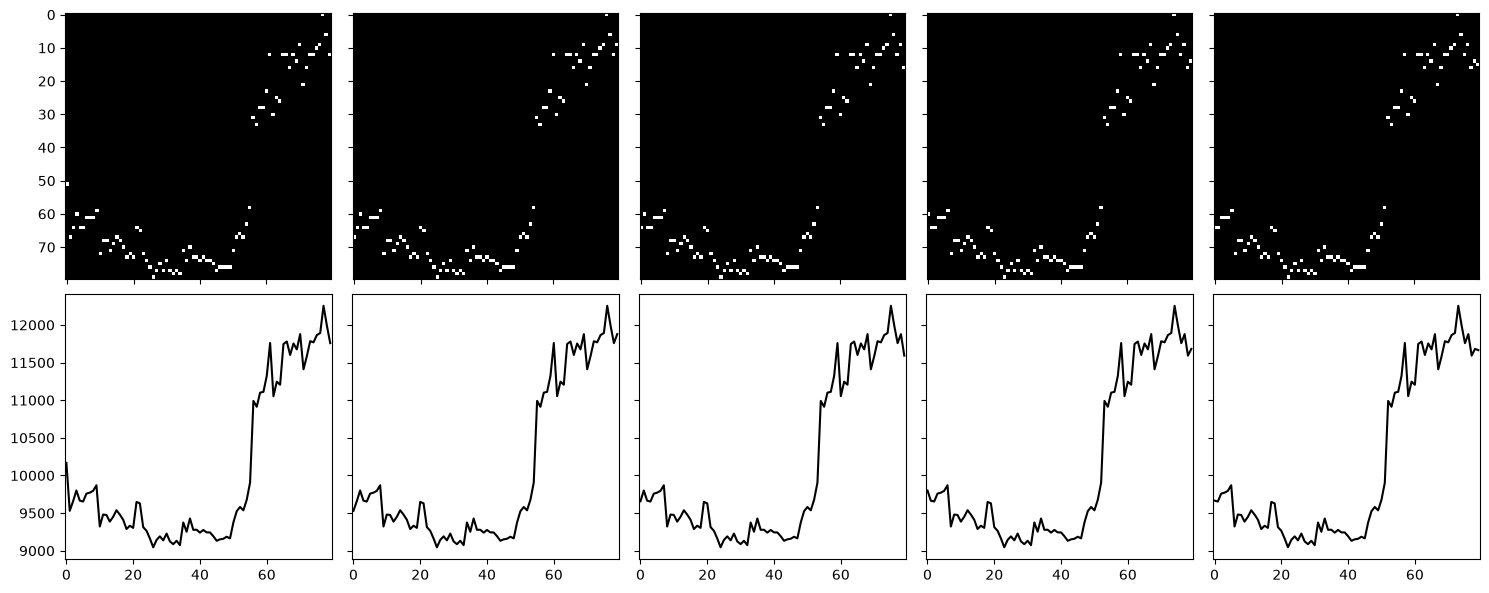

In [76]:
def compare_series_charts(steps=5):
    _, ax = plt.subplots(nrows=2,
                         ncols=steps,
                         figsize=(steps * 3, 6),
                         sharey='row',
                         sharex='col')
    for i in range(steps):
        ax[0][i].imshow(images[i], cmap='gray')
        ax[1][i].plot(windows[i], color='black')
    plt.tight_layout()
    plt.show()
compare_series_charts()

### X, Y division
Taking images and erasing the end of it - our models will have to predict that, so targets will be complete images representing time-series.

Copies:
* .copy() on np.ndarray - deep copy, totally separated
* .copy() on list - shallow copy, nested lists are mutable
* a = b - reference to the same object in memory

In [77]:
limit = 60 # 75% of full window
X = np.array(images).copy()
Y = np.array(images).copy()
X[:, :, limit:] = 0

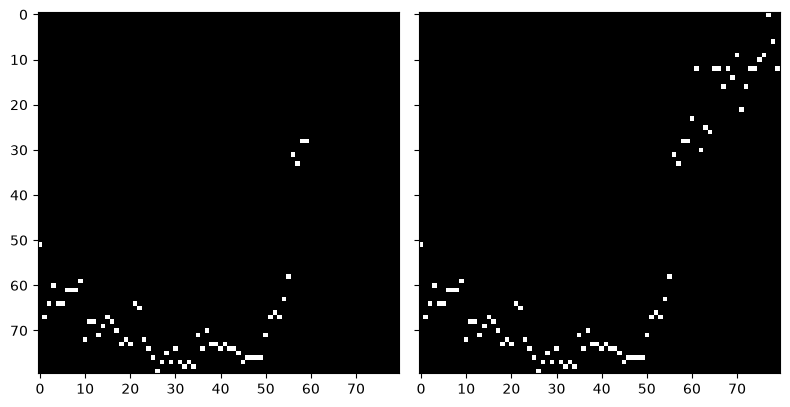

In [78]:
def show_x_and_target_difference():
    _, ax = plt.subplots(nrows=1,
                         ncols=2,
                         figsize=(8, 6),
                         sharey='row')
    ax[0].imshow(X[0], cmap='gray')
    ax[1].imshow(Y[0], cmap='gray')
    plt.tight_layout()
    plt.show()
show_x_and_target_difference()

## Visual Auto-Encoder Implementation

### What to improve later
* number of layers
* add batch normalization
* experiment with kernel sizes, stride, padding, dilation

### Quick recap
* kernel - filter that is being learned like 3x3, 5x5 matrix which goes through each image
* padding - addition of 0s to the borders to prevent image from shrinking
* stride - the step that each kernel takes
* dilation - how much we want kernel to expand - gain wider receptive field, but could lead to information being lost

### Encoder

In [128]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 32, 3, 1, 1)
        self.conv3 = nn.Conv2d(32, 16, 3, 1, 1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(16 * 80 * 80, 128)

    def forward(self, x):
        print('input:', x.shape) # NCHW
        x = self.relu(self.conv1(x))
        print('conv1:', x.shape)
        x = self.relu(self.conv2(x))
        print('conv2:', x.shape)
        x = self.relu(self.conv3(x))
        print('conv3:', x.shape)
        x = self.flatten(x)
        print('flatten:', x.shape)
        x = self.linear(x)
        print('linear:', x.shape)
        return x


### Decoder

In [129]:
class Decoder(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear = nn.Linear(in_features, 102400)
        self.conv1 = nn.ConvTranspose2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.ConvTranspose2d(32, 64, 3, 1, 1)
        self.conv3 = nn.ConvTranspose2d(64, 1, 3, 1, 1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        print('input:', x.shape) # latent space
        x = self.linear(x)
        print('linear:', x.shape)
        x = x.reshape(x.shape[0], 16, 80, 80)
        print('reshaped:', x.shape)
        x = self.relu(self.conv1(x))
        print('conv1:', x.shape)
        x = self.relu(self.conv2(x))
        print('conv2:', x.shape)
        x = self.relu(self.conv3(x))
        print('conv3:', x.shape)
        x = self.sigmoid(x)
        return x

### Testing Encoder and Decoder

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]])


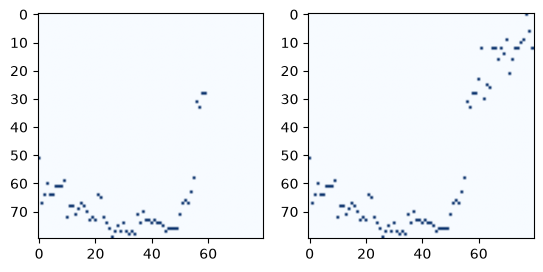

In [134]:
t = torch.tensor(X[0]).unsqueeze(0).unsqueeze(0)
print(t)
_, ax = plt.subplots(1, 2)
ax[0].imshow(X[0], cmap='Blues')
ax[1].imshow(Y[0], cmap='Blues')
plt.show()

In [135]:
encoder = Encoder()
decoder = Decoder(in_features=128)

latent = encoder(t)
output = decoder(latent)

input: torch.Size([1, 1, 80, 80])
conv1: torch.Size([1, 64, 80, 80])
conv2: torch.Size([1, 32, 80, 80])
conv3: torch.Size([1, 16, 80, 80])
flatten: torch.Size([1, 102400])
linear: torch.Size([1, 128])
input: torch.Size([1, 128])
linear: torch.Size([1, 102400])
reshaped: torch.Size([1, 16, 80, 80])
conv1: torch.Size([1, 32, 80, 80])
conv2: torch.Size([1, 64, 80, 80])
conv3: torch.Size([1, 1, 80, 80])


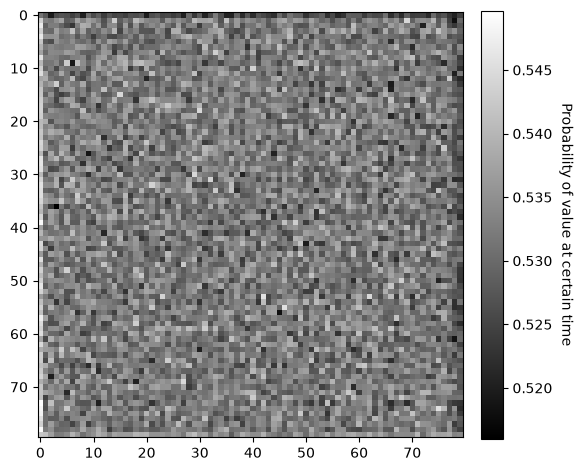

In [181]:
img_array = output.squeeze().detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(img_array, cmap='gray')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Probability of value at certain time', rotation=270, labelpad=15)

plt.show()

## Loss
The loss is presented as the sum of distances $d$ between columns in our predicted and true images. 

$$L(y, \hat{y}) = \sum_{i=1}^{w} d(y_i, \hat{y}_i),$$

Where $y$ and $\hat{y}$ represent input image and target image respectively. $w$ is image width and we are summing the distance $d$ of columns $y_i$ (input column) and $\hat{y}_i$ (target column)

In this case our $d$ will be *Jensen-Shannon Divergence* (JSD). It is a more stable version of *Kullback-Leibler Divergence*.

In [234]:
y_pred = torch.tensor([[[0, 0, 0.5, 0.5, 0],
                        [0, 0.1, 0.6, 0.25, 0.05],
                        [0, 0.7, 0.2, 0.05, 0.05]],
                       [[0, 0, 0.5, 0.5, 0],
                        [0, 0.1, 0.6, 0.25, 0.05],
                        [0, 0.7, 0.2, 0.05, 0.05]]])
y_true = torch.tensor([[0, 0, 1, 0, 0],
                       [0, 0, 0, 1, 0],
                       [0, 0, 0, 0, 1]])
# y_pred / (y_true + 1e-8)
# y_pred / (y_pred.sum(dim=0) + 1e-8)
y_pred.sum(dim=1).mean(dim=1)

tensor([0.6000, 0.6000])

In [ ]:
def loss(y_pred, y_true):
    '''Sum of column-wise distances between the two images'''
    # Remove dim: [N, 1, H, W] -> [N, H, W]
    y_pred = y_pred.squeeze(1) # channel dim
    y_true = y_true.squeeze(1)
    epsilon = 1e-8 # prevents from division by 0

    # Computing vertical sums
    col_sums_pred = y_pred.sum(dim=1)
    col_sums_true = y_true.sum(dim=1)

    # Using these sums to transform cols into discrete probability distributions P and Q
    Q = y_pred / (col_sums_pred + epsilon)
    P = y_true / (col_sums_true + epsilon)
    # Now every column in image is a distribution

    # Get mean distribution
    M = 0.5 * (P + Q)

    # Computing Kullback-Leibler Divergence
    kl_p_m = F.kl_div(M.log(), P, reduction='none')
    kl_q_m = F.kl_div(M.log(), Q, reduction='none')

    # JSD
    # Getting error for each column
    # Getting mean for each batch across columns
    jsd = (kl_p_m + kl_q_m).sum(dim=1).mean(dim=1)
    return jsd
loss(y_pred, y_true)

RuntimeError: The size of tensor a (5) must match the size of tensor b (3) at non-singleton dimension 1